<a href="https://colab.research.google.com/github/JessCodeRep/DS-portifolio/blob/main/CustomerSegmentation_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Sobre o Conjunto de Dados

A análise de segmentação de clientes é uma investigação dos perfis de clientes ideais de uma empresa. Essa análise facilita uma compreensão mais profunda dos tipos de clientes que o Empório Mercadinho atende, permitindo que os produtos ofertados para os clientes estejam mais próximos para atender às necessidades, comportamentos e preocupações distintas de vários tipos de clientes. Ao realizar uma análise do perfil dos clientes, foi possível que o Empório Mercadinho adotasse novas estratégias de negócios de modo a ampliar vendas através da oferta mais direcionada aos grupos, assim ocmo campanhas de marketing mais efetivas considerando os segmentos específicos, otimizando a utilização de recursos e aumentando a probabilidade de adoção bem-sucedida do produto.

Variáveis:

* ID: Identificador exclusivo para cada indivíduo no conjunto de dados.
* Year_Birth: O ano de nascimento do indivíduo.
* Education: O nível mais alto de escolaridade alcançado pelo indivíduo.
* Marital_Status: O estado civil do indivíduo.
* Income: A renda anual do indivíduo.
* Kidhome: O número de crianças pequenas na residência.
* Teenhome: Número de adolescentes na residência.
* Dt_Customer: Data em que o cliente foi cadastrado ou passou a fazer parte do banco de dados da empresa.
* Recency: Número de dias desde a última compra ou interação.
* MntWines: Valor gasto em vinhos.
* MntFruits: Valor gasto em frutas.
* MntMeatProducts: Valor gasto em produtos cárneos.
* MntFishProducts: Valor gasto em produtos de peixe.
* MntSweetProducts: Valor gasto em doces.
* MntGoldProds: Valor gasto em produtos de ouro.
* NumDealsPurchases: Número de compras realizadas com desconto ou como parte de uma promoção.
* NumWebPurchases: Número de compras realizadas pelo site da empresa.
* NumCatalogPurchases: Número de compras realizadas por catálogo.
* NumStorePurchases: Número de compras realizadas em lojas físicas.
* NumWebVisitsMonth: Número de visitas ao site da empresa em um mês.
* AcceptedCmp1: Indicador binário (1 ou 0) que indica se o indivíduo aceitou a primeira campanha de marketing.
* AcceptedCmp2: Indicador binário (1 ou 0) que indica se o indivíduo aceitou a segunda campanha de marketing.
* AcceptedCmp3: Indicador binário (1 ou 0) que indica se o indivíduo aceitou a terceira campanha de marketing.
* AcceptedCmp4: Indicador binário (1 ou 0) que indica se o indivíduo aceitou a quarta campanha de marketing.
* AcceptedCmp5: Indicador binário (1 ou 0) que indica se o indivíduo aceitou a quinta campanha de marketing.
* Complain: Indicador binário (1 ou 0) que indica se o indivíduo fez uma reclamação.
* Z_CostContact: Custo constante associado ao contato com um cliente.
* Z_Revenue: Receita constante associada a uma resposta bem-sucedida à campanha.
* Response: Indicador binário (1 ou 0) que indica se o indivíduo respondeu à campanha de marketing.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("/content/drive/MyDrive/Mentoria de Ciência de Dados/DataSets/customer_segmentation.csv")

# Conhecendo os dados

EDA - Análise Exploratória

In [4]:
#contagem de nulo
df.isnull().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


<Axes: >

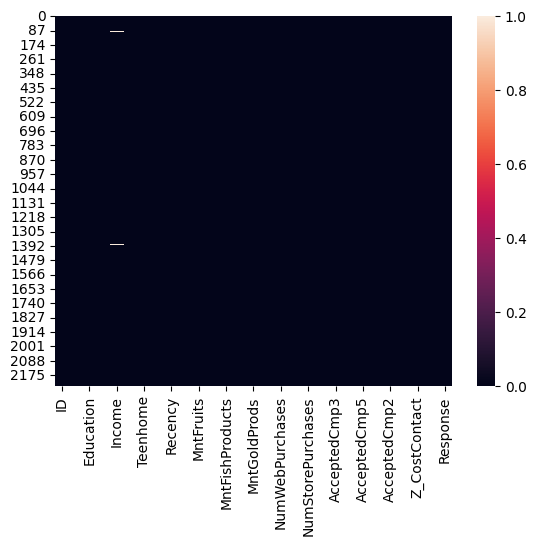

In [5]:
# Presença de valores nulos
sns.heatmap(df.isnull())

In [6]:
#duplicatas
df.duplicated().sum()

np.int64(0)

In [7]:
#estatística descritiva
df.describe()


,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


array([[<Axes: title={'center': 'ID'}>,
        <Axes: title={'center': 'Year_Birth'}>,
        <Axes: title={'center': 'Income'}>,
        <Axes: title={'center': 'Kidhome'}>,
        <Axes: title={'center': 'Teenhome'}>],
       [<Axes: title={'center': 'Recency'}>,
        <Axes: title={'center': 'MntWines'}>,
        <Axes: title={'center': 'MntFruits'}>,
        <Axes: title={'center': 'MntMeatProducts'}>,
        <Axes: title={'center': 'MntFishProducts'}>],
       [<Axes: title={'center': 'MntSweetProducts'}>,
        <Axes: title={'center': 'MntGoldProds'}>,
        <Axes: title={'center': 'NumDealsPurchases'}>,
        <Axes: title={'center': 'NumWebPurchases'}>,
        <Axes: title={'center': 'NumCatalogPurchases'}>],
       [<Axes: title={'center': 'NumStorePurchases'}>,
        <Axes: title={'center': 'NumWebVisitsMonth'}>,
        <Axes: title={'center': 'AcceptedCmp3'}>,
        <Axes: title={'center': 'AcceptedCmp4'}>,
        <Axes: title={'center': 'AcceptedCmp5'}>],


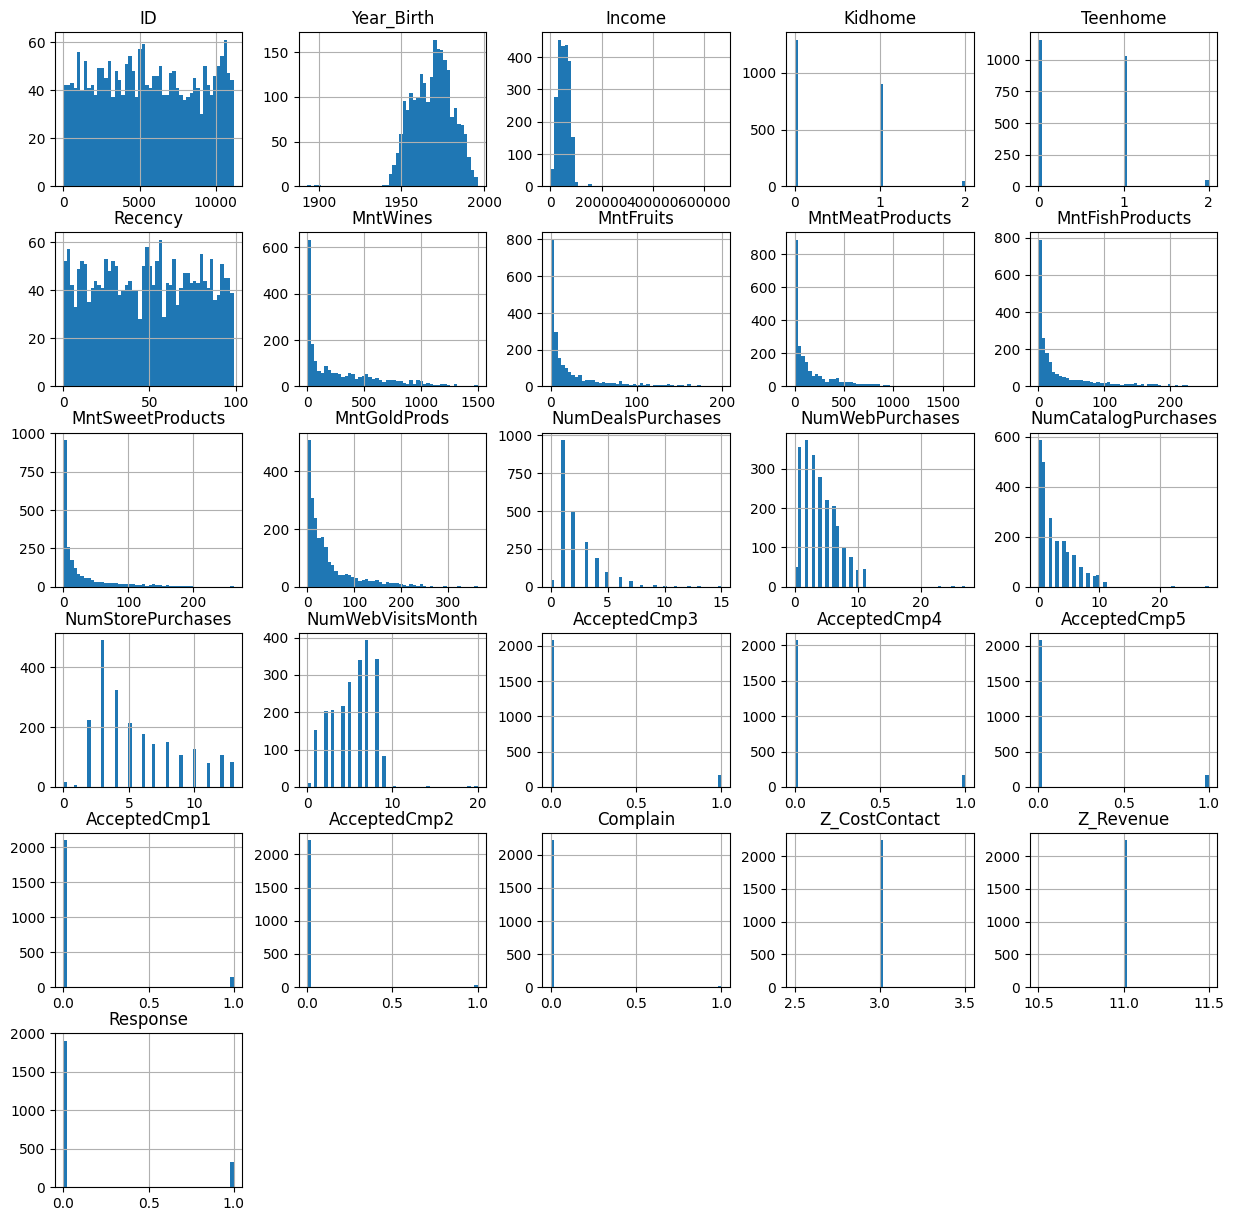

In [8]:
#Como é a distribuição das variáveis numéricas
df.hist(figsize=(15,15), bins=50)

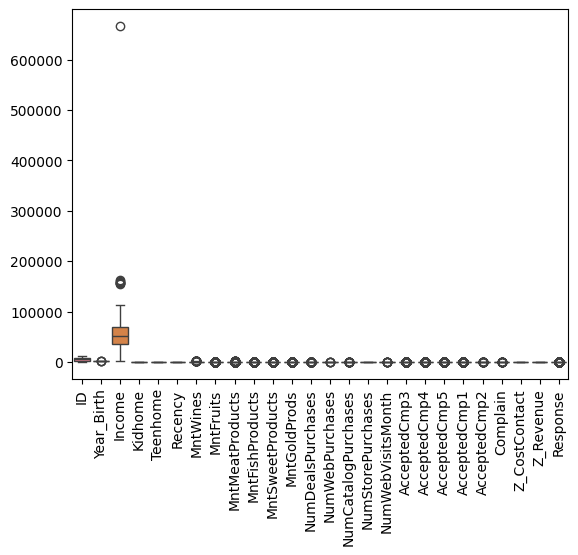

In [9]:
#Identificação de outliers
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

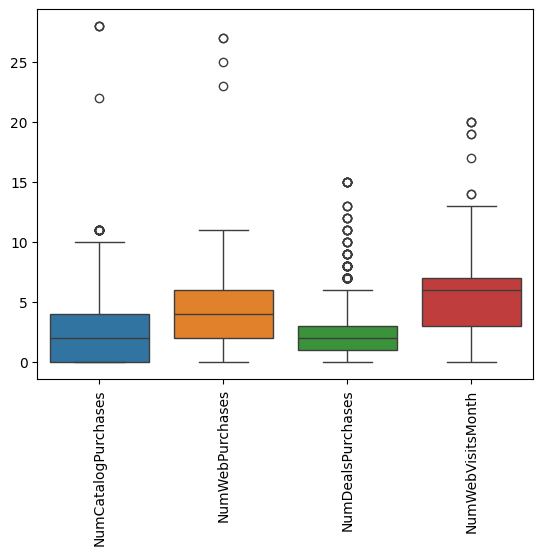

In [10]:
#Identificação de outliers das colunas mascaradas pelo Income
sns.boxplot(data=df[['NumCatalogPurchases','NumWebPurchases','NumDealsPurchases','NumWebVisitsMonth']])
plt.xticks(rotation=90)
plt.show()

# Tratamento dos dados e Feature Enginnering

Limpeza, Tratamento dos dados e Feature Enginnering

In [11]:
#Agrupar Estado Civil
map_civil = {
    'Absurd': 'AbsurdYOLO',
    'Married': 'TogetherMarried',
    'Together': 'TogetherMarried',
    'Single': 'SingleAlone',
    'Alone': 'SingleAlone',
    'Divorced': 'Divorced',
    'Widow': 'Widow',
    'YOLO': 'AbsurdYOLO'
}

df['Gpd'] = df['Marital_Status'].map(map_civil)

In [12]:
#One Hot Encoder coluna categórica de Estado civil
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False)

encoded = encoder.fit_transform(df[['Gpd']])

encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out()
)

df = pd.concat([df, encoded_df], axis=1)

In [13]:
#Quantidade de dias do primeiro registro
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'],format='%d-%m-%Y')
df['First_Register'] = (pd.Timestamp.today()-df['Dt_Customer']).dt.days

In [14]:
#Cálculo da idade a partir do ano de nascimento
from datetime import datetime

def idade(df, column):
  df[column] = datetime.now().year - df['Year_Birth']
  return df


df = idade(df, 'Age')

In [15]:
#print("Data mínima:", df['Dt_Customer'].min())
#print("Data máxima:", df['Dt_Customer'].max())

In [16]:
#Quantidade de filhos
def qtd_filhos(df, column):
  df[column] = df['Kidhome'] + df['Teenhome']
  return df

df = qtd_filhos(df, 'Childhome')

In [17]:
#Label Encoder para a coluna de nível educacional
from sklearn.preprocessing import LabelEncoder

le_education = LabelEncoder()
df['EducationLevel'] = le_education.fit_transform(df['Education'])

In [18]:
dict(zip(le_education.classes_, le_education.transform(le_education.classes_)))

{'2n Cycle': np.int64(0),
 'Basic': np.int64(1),
 'Graduation': np.int64(2),
 'Master': np.int64(3),
 'PhD': np.int64(4)}

In [19]:
numericas = df.select_dtypes(include='number')

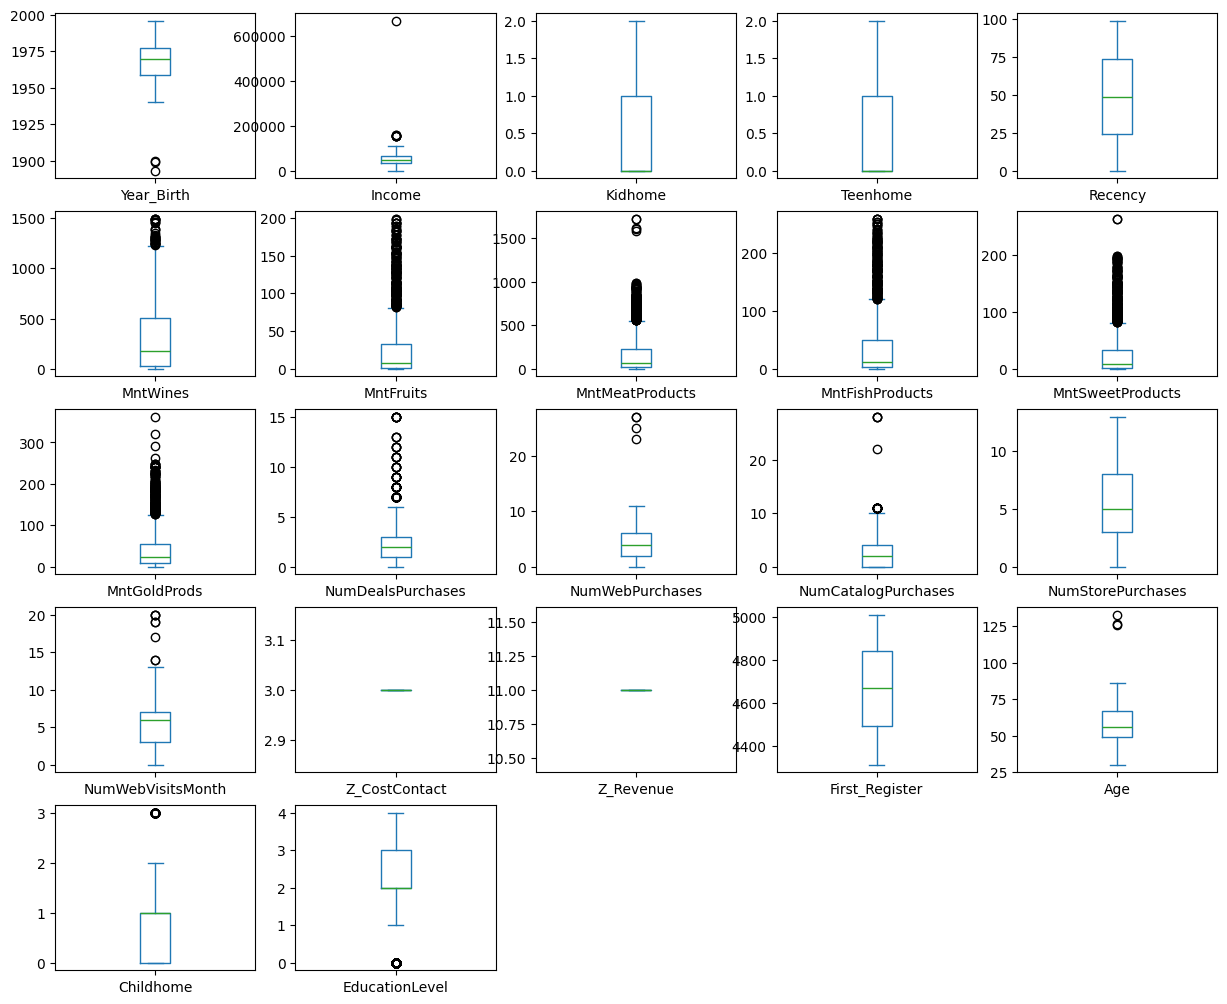

In [20]:
#numericas = df.select_dtypes(include='number')

numericas.drop(columns=['ID','AcceptedCmp3','AcceptedCmp2','AcceptedCmp1','AcceptedCmp4','AcceptedCmp5','Complain','Response','Gpd_Divorced','Gpd_SingleAlone','Gpd_TogetherMarried','Gpd_Widow','Gpd_AbsurdYOLO']).plot(
    kind='box',
    subplots=True,
    layout=(6,5),
    figsize=(15,15)
)

plt.show()

In [21]:
df_out = df.copy()

Remoção de Outliers através da clipagem

In [22]:
#Função para limitar os outliers
def clip_outliers(df, columns):
  for column in columns:
    inferior_limit = df[column].quantile(0.05)
    superior_limit = df[column].quantile(0.95)
    df[column] = np.clip(
    df[column], inferior_limit, superior_limit
    )
  return df

In [23]:
#Criar lista para limpeza de outliers e não considerar colunas numericas que não necessitam do tratamento
lista_clip = [col for col in numericas if col not in ['ID','Kidhome','Teenhome','Recency','MntWines','MntFruits','MntFishProducts','AcceptedCmp3','AcceptedCmp2','AcceptedCmp1','AcceptedCmp4','AcceptedCmp5','Complain','Response','Z_CostContact','Z_Revenue','NumStorePurchases','Gpd_Divorced','Gpd_SingleAlone','Gpd_TogetherMarried','Gpd_Widow','Gpd_AbsurdYOLO']]

In [24]:
#Função para limitar os outliers (corrigida)
def clip_outliers(df, columns):
  for column in columns:
    inferior_limit = df[column].quantile(0.05)
    superior_limit = df[column].quantile(0.95)
    df[column] = df[column].clip(lower=inferior_limit, upper=superior_limit)
  return df

#Clipar as features da lista
df_out = clip_outliers(df_out, lista_clip)

In [25]:
new_df = df_out.copy()

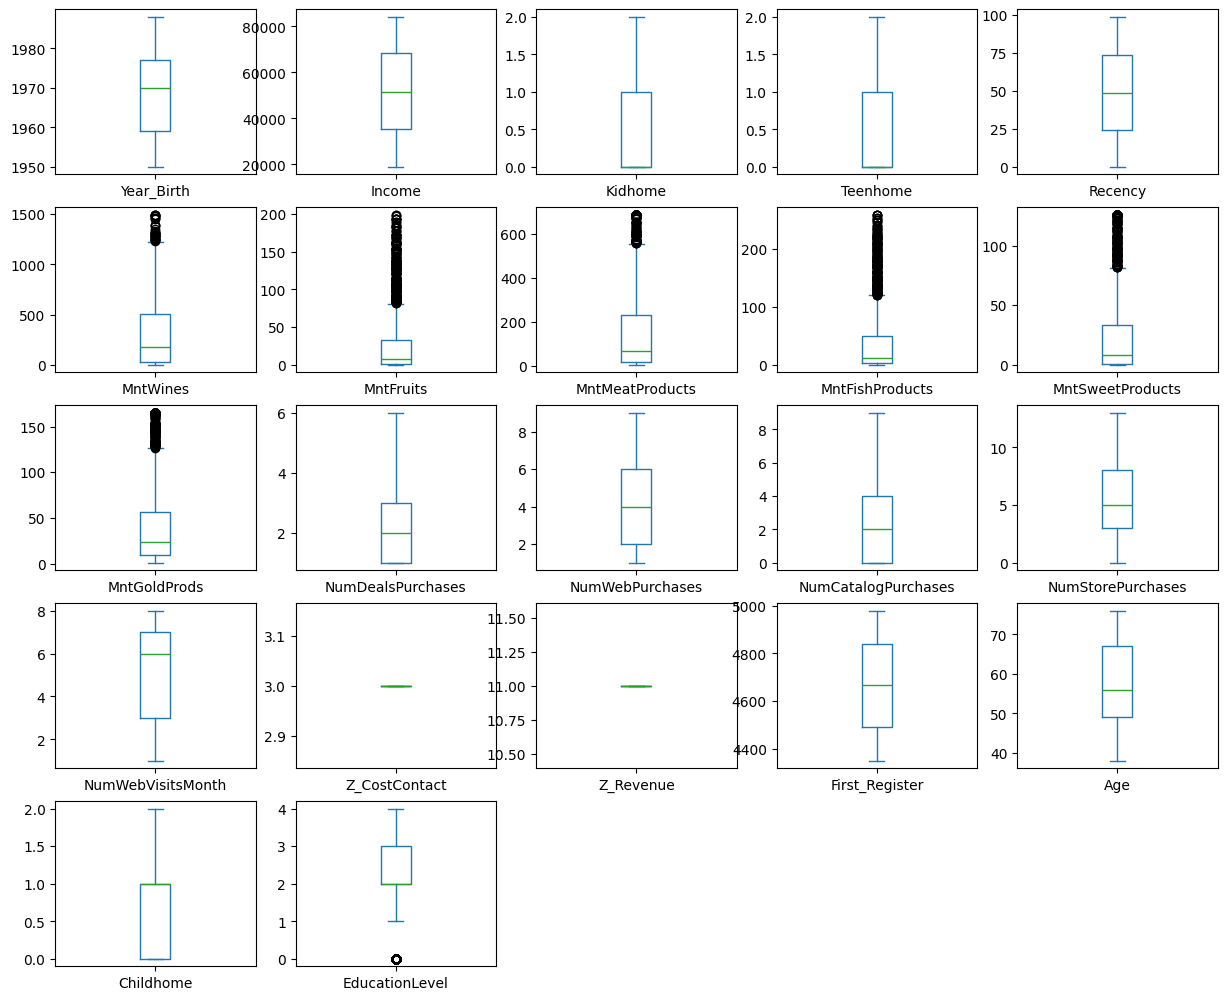

In [26]:
numericas_new = new_df.select_dtypes(include='number')

numericas_new.drop(columns=['ID','AcceptedCmp3','AcceptedCmp2','AcceptedCmp1','AcceptedCmp4','AcceptedCmp5','Complain','Response','Gpd_Divorced','Gpd_SingleAlone','Gpd_TogetherMarried','Gpd_Widow','Gpd_AbsurdYOLO']).plot(
    kind='box',
    subplots=True,
    layout=(6,5),
    figsize=(15,15)
)

plt.show()

In [27]:
#Função para remoção/redução de assimetria com Yeo-Johnson (aceita valores negativos)
from sklearn.preprocessing import PowerTransformer

def aplicar_yeojohnson(df, columns_list):
    pt = PowerTransformer(method='yeo-johnson')
    if isinstance(columns_list, str):
        columns_list = [columns_list]

    # # Aplicar transformação às colunas selecionadas na lista
    df[columns_list] = pt.fit_transform(df[columns_list])

    return df

In [28]:
#lista_yeojohnson = [col for col in numericas if col not in ['ID','Kidhome','Teenhome','Year_Birth','Recency','AcceptedCmp3','AcceptedCmp2','AcceptedCmp1','AcceptedCmp4','AcceptedCmp5','Complain','Response','Z_CostContact','Z_Revenue','NumStorePurchases','NumCatalogPurchases','NumDealsPurchases']]
lista_yeojohnson = [col for col in ['MntWines','MntMeatProducts','MntSweetProducts','MntFishProducts','MntGoldProds','MntFruits']]

In [29]:
new_df = aplicar_yeojohnson(new_df, lista_yeojohnson)

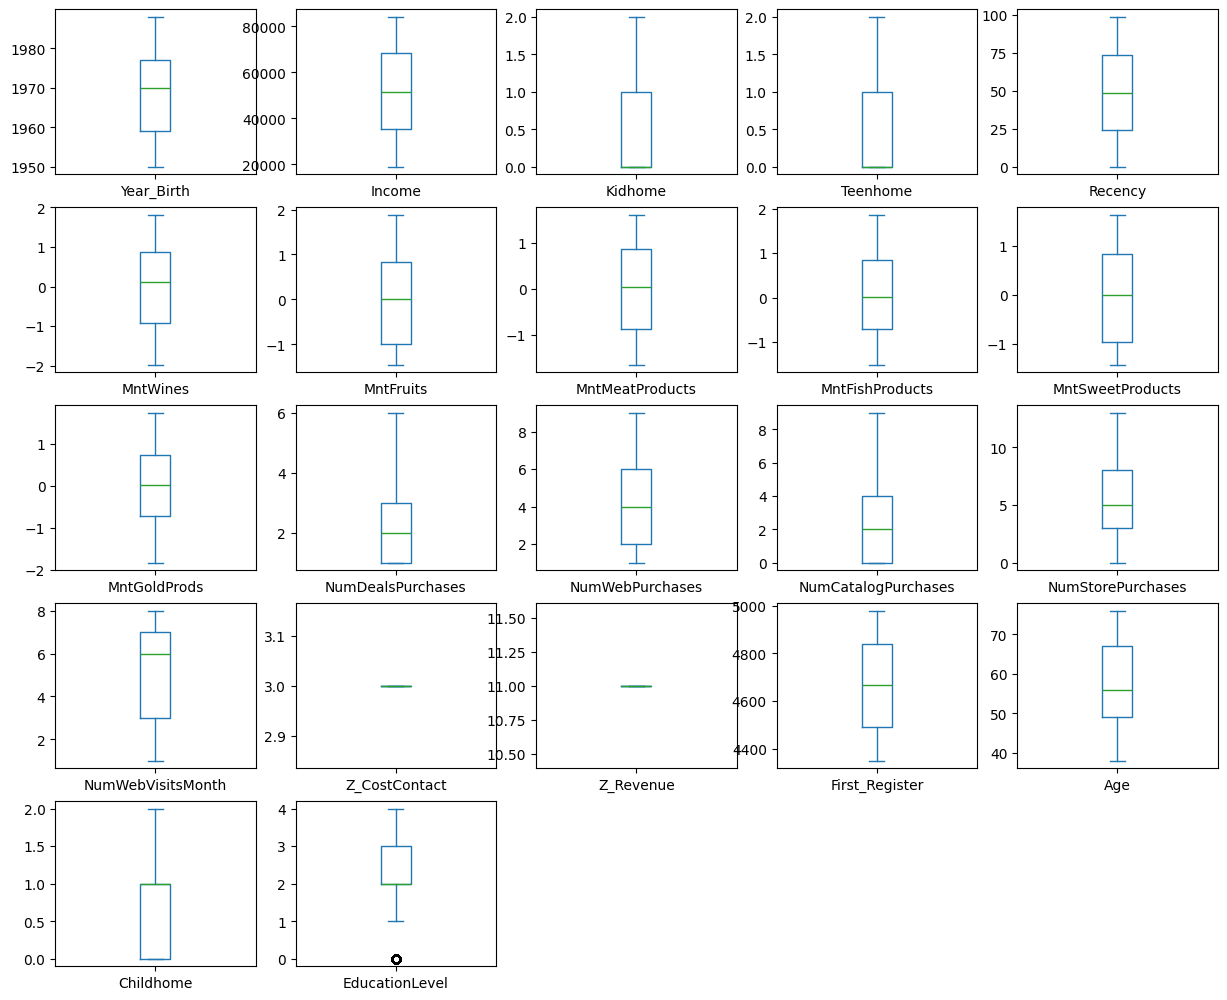

In [30]:
numericas_new = new_df.select_dtypes(include='number')

numericas_new.drop(columns=['ID','AcceptedCmp3','AcceptedCmp2','AcceptedCmp1','AcceptedCmp4','AcceptedCmp5','Complain','Response','Gpd_Divorced','Gpd_SingleAlone','Gpd_TogetherMarried','Gpd_Widow','Gpd_AbsurdYOLO']).plot(
    kind='box',
    subplots=True,
    layout=(6,5),
    figsize=(15,15)
)

plt.show()

In [31]:
#Importando pacote para imputar dados via KNN
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler

In [32]:
lista_padronizacao = [col for col in ['Income','Recency','NumDealsPurchases','NumWebPurchases','NumCatalogPurchases','NumStorePurchases','NumWebVisitsMonth','Age','First_Register','Z_CostContact','Z_Revenue']]

In [33]:
#Normalizar os dados pois o KNN utiliza as distâncias
scaler = StandardScaler()
new_df[lista_padronizacao]= scaler.fit_transform(new_df[lista_padronizacao])

In [34]:
# KNN Imputer considerando os 5 vizinhos com peso de distância
imputer = KNNImputer(
    n_neighbors=5,
    weights='distance'
)
new_df[['Income']] = imputer.fit_transform(new_df[['Income']])

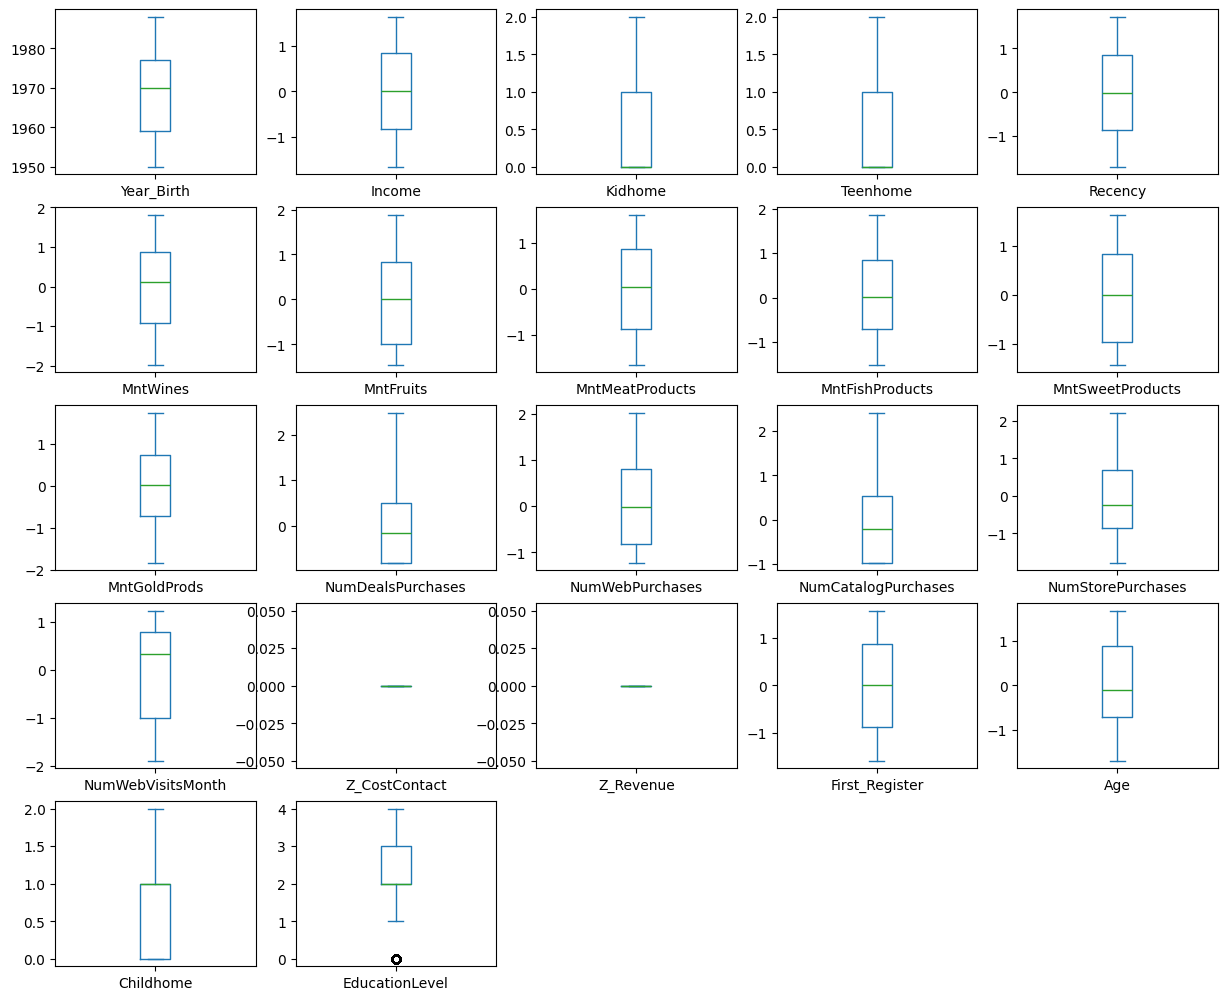

In [35]:
numericas_new = new_df.select_dtypes(include='number')

numericas_new.drop(columns=['ID','AcceptedCmp3','AcceptedCmp2','AcceptedCmp1','AcceptedCmp4','AcceptedCmp5','Complain','Response','Gpd_Divorced','Gpd_SingleAlone','Gpd_TogetherMarried','Gpd_Widow','Gpd_AbsurdYOLO']).plot(
    kind='box',
    subplots=True,
    layout=(6,5),
    figsize=(15,15)
)

plt.show()

# Modelagem

Modelo de clusterização utilizado KMeans

In [36]:
from sklearn.cluster import KMeans

In [37]:
#Lista que seleciona quais colunas serão utilizadas para treinar o modelo
lista_modelo = [col for col in ['Income','Age','Childhome','EducationLevel','Gpd_Divorced','Gpd_SingleAlone','Gpd_TogetherMarried','Gpd_Widow']]
X = new_df[lista_modelo]

Investigar o número ideal de clusters:

1. Elbow Method
2. Calinski-Harabasz Score
3. Silhouette Score

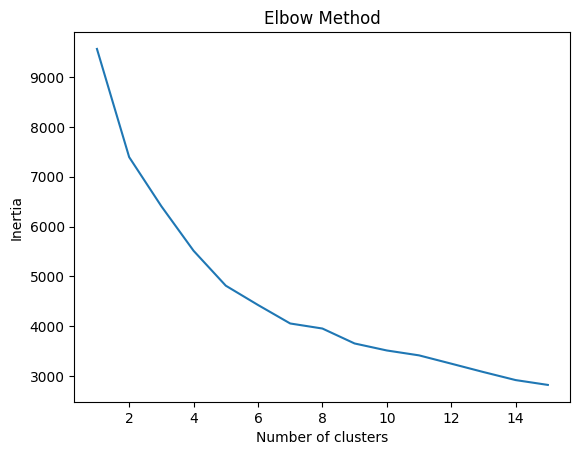

In [38]:
#Número ideal de clusters

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertia = []

for k in range (1,16):
  kmeans = KMeans(n_clusters=k, random_state=42)
  kmeans.fit(X)
  inertia.append(kmeans.inertia_)

plt.plot(range(1,16), inertia)
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

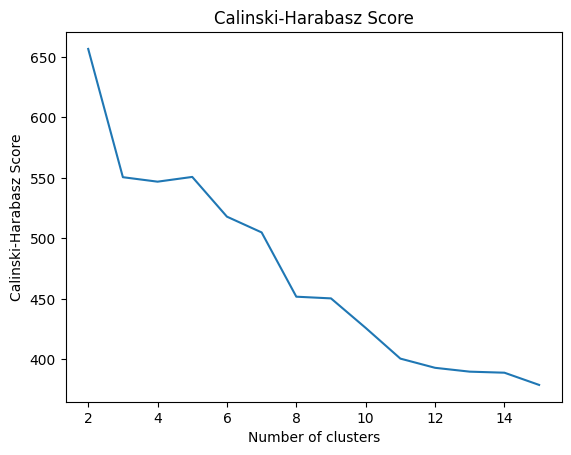

In [39]:
from sklearn.cluster import KMeans
from sklearn.metrics import calinski_harabasz_score
import matplotlib.pyplot as plt

calinski_scores = []

for k in range(2, 16):  # começa em 2 pois não existe cluster único
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)

    score = calinski_harabasz_score(X, labels)
    calinski_scores.append(score)

plt.plot(range(2, 16), calinski_scores)
plt.title('Calinski-Harabasz Score')
plt.xlabel('Number of clusters')
plt.ylabel('Calinski-Harabasz Score')
plt.show()

In [40]:
#Validar com Silhuette Score

for k in range(2,10):
  kmeans = KMeans(n_clusters=k, random_state=42)
  labels = kmeans.fit_predict(X)
  sil_score = silhouette_score(X, labels)
  print(f"Silhouette Score for k={k}: {sil_score}")

Silhouette Score for k=2: 0.20980295178354674
Silhouette Score for k=3: 0.20764957004973233
Silhouette Score for k=4: 0.20776315305795542
Silhouette Score for k=5: 0.21409438774487943
Silhouette Score for k=6: 0.19746686195613006
Silhouette Score for k=7: 0.2060107539049286
Silhouette Score for k=8: 0.195379027326447
Silhouette Score for k=9: 0.20123234456660138


In [41]:
#Treinamento do modelo final

kmeans = KMeans(n_clusters=4, random_state=42)
new_df['Cluster'] = kmeans.fit_predict(X)

In [42]:
df_out['Cluster'] = new_df['Cluster']

# ***Análise dos dados***

**Clusterização Socioeconômica**

Entender quais são os principais perfis de clientes que atendo.



In [43]:
Perfil = df_out[['Age','Income','EducationLevel','Childhome','Kidhome','Teenhome','Gpd_Divorced','Gpd_SingleAlone','Gpd_TogetherMarried','Gpd_AbsurdYOLO','Gpd_Widow','Cluster']].groupby('Cluster').mean(numeric_only=True)

Perfil.loc['Media_Geral'] = Perfil.mean()

Perfil.round(3)


,Age,Income,EducationLevel,Childhome,Kidhome,Teenhome,Gpd_Divorced,Gpd_SingleAlone,Gpd_TogetherMarried,Gpd_AbsurdYOLO,Gpd_Widow
Cluster,,,,,,,,,,,
0,51.179,39409.571,0.222,0.889,0.551,0.350,0.081,0.214,0.684,0.000,0.021
1,52.741,35257.017,2.240,1.232,0.801,0.465,0.088,0.236,0.654,0.000,0.022
2,61.574,55970.896,3.770,1.025,0.374,0.686,0.109,0.185,0.646,0.003,0.056
3,59.913,70458.616,2.075,0.512,0.075,0.443,0.123,0.221,0.619,0.003,0.033
Media_Geral,56.352,50274.025,2.077,0.914,0.450,0.486,0.100,0.214,0.651,0.002,0.033


Perfil de aderência em campanhas de marketing: Entender como cada grupo reage as campanhas de marketing.

In [44]:
MKT = df_out[['Recency','NumDealsPurchases','AcceptedCmp1','AcceptedCmp2','AcceptedCmp3','AcceptedCmp4','AcceptedCmp5','Complain','First_Register','Response','Cluster']].groupby('Cluster').mean(numeric_only=True)

MKT.loc['Media_Geral'] = MKT.mean()

MKT.round(4)

,Recency,NumDealsPurchases,AcceptedCmp1,AcceptedCmp2,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,Complain,First_Register,Response
Cluster,,,,,,,,,,
0,49.0128,2.1368,0.0214,0.0085,0.0812,0.0385,0.0299,0.0171,4687.6197,0.0855
1,49.0882,2.4573,0.0041,0.0000,0.0746,0.0190,0.0000,0.0122,4666.4735,0.1058
2,48.5603,2.4083,0.0496,0.0182,0.0711,0.0959,0.0694,0.0017,4655.2033,0.1851
3,49.6672,1.8690,0.1596,0.0256,0.0693,0.1295,0.1717,0.0105,4666.8163,0.1867
Media_Geral,49.0821,2.2178,0.0587,0.0131,0.0740,0.0707,0.0678,0.0104,4669.0282,0.1408


Perfil de consumo: Entender quais produtos sao mais consumdos por cluters

In [45]:
import numpy as np

# Agrupamento por cluster
Consumo = df_out[
    ['Income','MntWines','MntFruits','MntMeatProducts',
     'MntFishProducts','MntSweetProducts',
     'MntGoldProds','Cluster']
].groupby('Cluster').mean(numeric_only=True)

# Colunas de gasto
cols = [
    'Income',
    'MntWines',
    'MntFruits',
    'MntMeatProducts',
    'MntFishProducts',
    'MntSweetProducts',
    'MntGoldProds'
]

# Média e desvio padrão da base
media_base = df_out[cols].mean()
std_base = df_out[cols].std()

# Z-score
for col in cols:
    Consumo[col + '_zscore'] = (
        (Consumo[col] - media_base[col]) / std_base[col]
    ).round(2)

# Criar tabela categórica
Consumo_categoria = Consumo.copy()

for col in cols:
    z = Consumo[col + '_zscore']

    Consumo_categoria[col + '_Perfil'] = np.select(
        [z > 0.5, z < -0.5],
        ['Alto', 'Baixo'],
        default='Médio'
    )

# Adicionar linha média geral
media_row = {}

for col in cols:
    media_row[col + '_zscore'] = 0
    media_row[col + '_Perfil'] = 'Médio'

Consumo_categoria.loc['Media_Geral'] = media_row

# Mostrar apenas categórico
cols_perfil = [col + '_Perfil' for col in cols]

Consumo_categoria[cols_perfil]

,Income_Perfil,MntWines_Perfil,MntFruits_Perfil,MntMeatProducts_Perfil,MntFishProducts_Perfil,MntSweetProducts_Perfil,MntGoldProds_Perfil
Cluster,,,,,,,
0,Baixo,Baixo,Médio,Médio,Médio,Médio,Médio
1,Baixo,Baixo,Médio,Baixo,Médio,Médio,Médio
2,Médio,Médio,Médio,Médio,Médio,Médio,Médio
3,Alto,Alto,Alto,Alto,Alto,Alto,Alto
Media_Geral,Médio,Médio,Médio,Médio,Médio,Médio,Médio


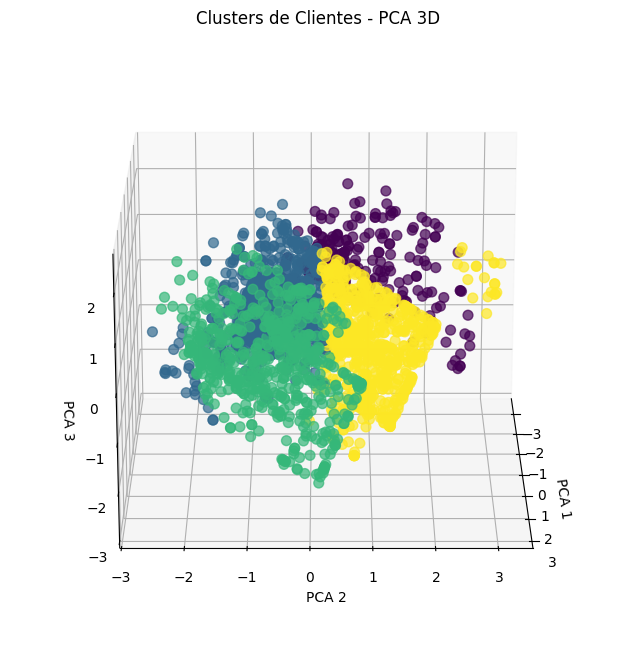

In [49]:
#PCA para "visualizar" como ficou a distribuição dos clusters

from matplotlib import pyplot as plt
from matplotlib.animation import FuncAnimation
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA # Import PCA

# Perform PCA before plotting
pca = PCA(n_components= 4) # Use 3 components for a 3D plot
X_pca = pca.fit_transform(X)

fig = plt.figure(figsize=(12,8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    X_pca[:,0],
    X_pca[:,1],
    X_pca[:,2],
    c=new_df['Cluster'],
    cmap='viridis',
    s=50,
    alpha=0.7
)

ax.set_xlabel('PCA 1')
ax.set_ylabel('PCA 2')
ax.set_zlabel('PCA 3')

plt.title('Clusters de Clientes - PCA 3D')

# Função de rotação
def rotate(angle):
    ax.view_init(elev=20, azim=angle)

# Criar animação
anim = FuncAnimation(fig, rotate, frames=range(0, 360, 2), interval=100)

# Salvar vídeo
anim.save('Clusters_PCA_3D.mp4', dpi=300)